# Laboratorio 1 - Parte 1 Regresión polinomial múltiple


In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources
replicating Labs resources


In [20]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L01.01", varname="student");

logging in as dalejandro.yepes@udea.edu.co... please wait

-------------
using course session introml::udea.pre.20251
success!! you are logged in
-------------


In [30]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab1 import *
_, db, x, y = part_1()
y = y.reshape(np.size(y), 1)

cargando librerias y variables al ambiente


## Ejercicio 1: Contextualización del problema

El problema de regresión que abordaremos consiste en predecir el valor de la humedad absoluta en el aire, a partir de varias variables sensadas en el aire (Para más información sobre la base de datos y la contextualización del problema, consulte: http://archive.ics.uci.edu/ml/datasets/air+quality).

In [31]:
# tienes ya cargadas las siguientes variables:
print("conjunto de datos", x)
print("variable a predecir", y)

conjunto de datos [[   2.6 1360.   150.  ... 1268.    13.6   48.9]
 [   2.  1292.   112.  ...  972.    13.3   47.7]
 [   2.2 1402.    88.  ... 1074.    11.9   54. ]
 ...
 [   2.4 1142.  -200.  ... 1092.    26.9   18.3]
 [   2.1 1003.  -200.  ...  770.    28.3   13.5]
 [   2.2 1071.  -200.  ...  816.    28.5   13.1]]
variable a predecir [[0.7578]
 [0.7255]
 [0.7502]
 ...
 [0.6406]
 [0.5139]
 [0.5028]]


In [32]:
#Ejercicio de Codigo
def num_muestras_carac(X):
  num_muestras, num_caracteristicas = X.shape

  return num_caracteristicas, num_muestras

**Registra tu solución en línea**

In [33]:
student.submit_task(namespace=globals(), task_id='T1');

## Ejercicio 2

Analice los siguientes métodos de la teoría  de modelos de  *regresión polinomial múltiple*:

1. error cuadrático medio (**ECM**)
2. modelo de regresión múltiple (**regression**)
3. calculo del costo de la regresión (**cost**)
4. extension de matriz (**extension_matriz**)

La siguiente celda contiene la implementación de estas 4 funciones. Analizar y entender su funcionamiento

In [45]:
def ECM(Y_est,Y):
    """función para calcular el error cuadratico medio
    Y_est: debe contener los valores predichos por el modelo
    Y: debe contener los valores reales
    retorna: error cuadratico medio
    """
    N = np.size(Y)
    ecm = np.sum((Y_est.reshape(N,1) - Y.reshape(N,1))**2)/(N)
    return ecm

def regression(X, W):
    """calcula la regresión multiple
    X: los valores que corresponden a las características
    W: son los pesos usadados para realizar la regresión
    retorna: valor estimado
    """
    Yest = np.dot(X,W)    #con np.dot se realiza el producto matricial. Aquí X es dim [Nxd] y W es dim [dx1]
    return Yest           #Esta variable contiene la salida de f(X,W)


def cost_f(W,X,Y):
    """calcula la función de costo de la regresión para un vector W dado
    W: son los pesos usadados para realizar la regresión
    X: los valores que corresponden a las caractersiticas
    Y: el valor de salida esperado

    retorna: valor de costo
    """

    m = len(Y)
    y_est = regression(X,W)
    cost = (1/2*m) * np.sum(np.square(y_est-Y))
    return cost

def extension_matriz(X):
    """función que realiza la extensión de la matriz X
    X: los valores que corresponden a las características sin extender
    Y: el valor de salida esperado

    retorna: X_ext: matriz con unos extendidos, Y: matriz con dimensiones ajustadas
    """
    #Obtenemos las dimensiones antes de exteneder la matriz
    caracterisitcas, muestras = num_muestras_carac(X)
    #Extendemos la matriz X
    unos = np.ones(muestras).reshape(-1,1)
    X_ext = np.concatenate((unos, X), axis=1)
    X_ext = X_ext.reshape(muestras, caracterisitcas+1)
    return X_ext


In [11]:
#Pregunta Abierta
#¿cual es el objetivo de la extension_matriz? recordar que estamos "ajustando" en una regresión

respuesta = 'Extension_matriz lo que hace es agregarle una columna de unos a la matriz X para que la regresión tenga en cuenta el término de sesgo. Esto es importante porque en la ecuación del modelo siempre hay un valor fijo que ayuda a que las predicciones sean más acertadas. Si no se hacemos esto puede no ajustarse bien a los datos. Es una forma de que la regresión funcione mejor y tenga más precisión'

Ahora vamos a completar el código de la regla de actualización de los parámetros del algoritmo de <font color='blue'>gradiente_descedente</font>:

$$w_j(iter) = w_j(iter-1) - \eta \frac{\partial E(w)}{\partial w_j}$$

recordar que

$$ \frac{\partial E(w)}{\partial w_j} = \frac{\partial E({\bf{w}})}{\partial w_j} = \frac{1}{N}\sum_{i=1}^{N}\left( f({\bf{x}}_i,{\bf{w}}) - y_i\right) \frac{\partial }{\partial w_j} f({\bf{x}}_i, {\bf{w}})$$

Recuerde que debe usar las funciones ya implementadas y no usar **ninguna otra libreria**, adicional a las librerias ya pre-cargadas como numpy (se puede llamar con np.)

In [35]:
## Ejercicio de codigo
def gradiente_descendente(X, Y, eta, iteraciones, w_ini = None):
    """Gradiente descendente para regresión lineal múltiple.

    X: Matriz de datos.
    Y: Vector con los valores a predecir.
    eta: Tasa de aprendizaje.
    iteraciones: Número de iteraciones del algoritmo.
    w_ini: Vector opcional con los parámetros iniciales del modelo.

    Retorna:
        - W: Valor final de los parámetros de la regresión.
        - costos: Array con el costo por iteración.
    """
    # Extender la matriz X para incluir el sesgo
    X_ext = extension_matriz(X)
    caracteristicas, N = num_muestras_carac(X_ext)

    # Inicializar los parámetros W
    if w_ini is not None:
        W = w_ini
    else:
        W = np.zeros((1, caracteristicas))

    W = W.reshape(np.size(W), 1)
    # Inicializar vector para almacenar costos
    costos = np.zeros(iteraciones)

    for i in range(iteraciones):
        # 1. Calcular las predicciones con la función de regresión
        y_est = regression(X_ext, W)

        # 2. Calcular el error (diferencia entre predicción y valores reales)
        f_xw_min_yi = y_est - Y.reshape(N, 1)

        # 3. Actualizar los pesos usando la regla del gradiente descendente
        W = W - (eta / N) * np.dot(X_ext.T, f_xw_min_yi)

        # 4. Guardar el costo para la iteración actual
        costos[i] = cost_f(W, X_ext, Y)

    return W, costos


**Registra tu solución en línea**

In [14]:
student.submit_task(namespace=globals(), task_id='T2');

## Ejercicio 3: Entrenamiento

Con la función implementada vamos a entrenar un modelo y calcular su error de entrenamiento. Antes de realizar esto, debemos separar nuestro conjunto de datos.

In [36]:
# esto para lograr reproductibilidad
# de nuestro modelo
random.seed(1)
# usamos nuestra funcion para obtener el numero de muestras
_, N = num_muestras_carac(x)
ind=np.random.permutation(N)
Xtrain = x[ind[0:int(math.ceil(0.7*N))],:]
Xtest = x[ind[int(math.ceil(0.7*N)):N],:]
Ytrain = y[ind[0:int(math.ceil(0.7*N))]]
Ytest = y[ind[int(math.ceil(0.7*N)):N]]

In [43]:
#Pregunta Abierta
# ¿Porqué debemos hacer partición de datos? ¿Qué representa Xtrain, qué diferencia tiene con Xtest?
respuesta = 'Debemos hacer partición de los datos para asegurarnos de que el modelo no solo aprende los datos con los que se entrena. Xtrain es el conjunto de datos para entrenar el modelo y Xtest es el conjunto de datos usado para evaluar como funciona el modelo con datos nuevos'

Ahora entrena ejecutando la siguiente linea de codigo y verifiquemos el comportamiento del costo

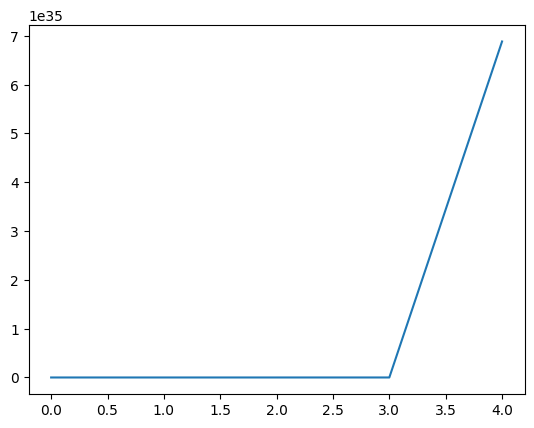

In [38]:
W, costo = gradiente_descendente(Xtrain, Ytrain, eta = 0.0001, iteraciones=5)
# graficar iteraciones y el costo
plt.plot(range(5), costo)
plt.show()

El costo es la medida que el algoritmo de optimización intenta mejorar. Sin embargo, para este tipo de problemas al final debemos evaluar que tan bien estamos modelando nuestra salida. Vamos a evaluar nuestro modelo calculando el error cuadrático medio. Para ello vamos crear a una función. Recuerda usar las funciones definidas anteriormente.

In [48]:
## Ejercicio de Código
def evaluar_modelo(W, X_to_test, Y_True):
    """Función que evalúa un modelo de regresión usando el error cuadrático medio.

    W: Matriz con los parámetros del modelo entrenado.
    X_to_test: Conjunto de datos para evaluación del modelo.
    Y_True: Valores reales para evaluar el modelo.

    Retorna: Error cuadrático medio (ECM).
    """
    # Extender la matriz de prueba para incluir el sesgo
    X_to_test_ext = extension_matriz(X_to_test)

    # Obtener las predicciones con el modelo entrenado
    y_est = regression(X_to_test_ext, W)

    # Calcular el error cuadrático medio
    N = np.size(Y_True)  # Número de muestras
    error = np.sum((y_est.reshape(N,1) - Y_True.reshape(N,1))**2) / N

    return(error)

**Registra tu solución en línea**

In [49]:
student.submit_task(namespace=globals(), task_id='T3');

In [44]:
# y ahora usala para calcular el error, para evaluar el modelo
error_train = evaluar_modelo(W, X_to_test = Xtrain,  Y_True = Ytrain)
print("error en entrenamiento del modelo", error_train)
error_test = evaluar_modelo(W, X_to_test = Xtest,  Y_True = Ytest)
print("error en la evaluación del modelo", error_test)

error en entrenamiento del modelo 3.209475962523192e+28
error en la evaluación del modelo 3.2093631762449274e+28


In [50]:
# ¿Que tan bueno es tu modelo?
respuesta = 'Debemos hacer partición de los datos para asegurarnos de que el modelo no solo aprende los datos con los que se entrena. Xtrain es el conjunto de datos para entrenar el modelo y Xtest es el conjunto de datos usado para evaluar como funciona el modelo con datos nuevos'

## Ejercicio 4: Polinomio de orden superior

Hasta ahora lo que hemos realizado es un regresión lineal de orden 1. Nuestro siguiente objetivo es tomar esta regresión y transformarla en un polinomio de mayor orden. Comprenda el funcionamiento de la función propuesta:

In [52]:
#Potencia de polinomio
def potenciaPolinomio(X,grado):
    """calcula la potencia del polinomio
    X: los valores que corresponden a las caractersiticas
    grado: es el grado para realizar la potencia al polinomio
    retorna: el valor de X despues de elevarlo al grado del polinimoo indicado
    """
    X2 = X.copy()

    if grado != 1:
        for i in range(2,grado+1):
            Xadd = X**i
            X2 = np.concatenate((X2, Xadd), axis=1)

    return X2

ahora debemos usar esta función para completar la siguiente.
**PISTAS**
- Usa las funciones previamente construidas
- Para completar `gradiente_descendente_poly` Tener presente que buscamos realizar este proceso: aplicar la `potenciaPolinomio` ->  aplicar gradiente descendente
- Para completar `evaluar_modelo_poly` Tener presente que buscamos realizar este proceso: aplicar la `potenciaPolinomio`  -> evaluar el modelo

In [53]:
## Ejercicio de codigo
def gradiente_descendente_poly(X, Y, eta, iteraciones, grado):
    """Gradiente descendente para regresión polinomial múltiple.

    X: Matriz de datos originales.
    Y: Vector con los valores a predecir.
    eta: Tasa de aprendizaje.
    iteraciones: Número máximo de iteraciones para el gradiente descendente.
    grado: Grado del polinomio a usar.

    Retorna:
        - W: El valor de los parámetros de regresión polinómica entrenados.
        - costo: Array con el valor del costo por cada iteración.
    """
    # Aplicar transformación polinómica a los datos
    X2 = potenciaPolinomio(X, grado)

    # Aplicar el algoritmo de gradiente descendente sobre los datos transformados
    W, costo = gradiente_descendente(X2, Y, eta, iteraciones)

    return W, costo

def evaluar_modelo_poly(W, X_to_test, Y_True, grado):
    """Función que evalúa un modelo de regresión polinomial usando el error cuadrático medio.

    W: Matriz con los parámetros del modelo entrenados.
    X_to_test: Conjunto de datos para evaluación del modelo.
    Y_True: Valores reales para evaluar el modelo.
    grado: Grado del polinomio a usar.

    Retorna: Error cuadrático medio (ECM).
    """
    # Aplicar transformación polinómica a los datos de prueba
    X2 = potenciaPolinomio(X_to_test, grado)

    # Evaluar el modelo sobre los datos transformados
    error = evaluar_modelo(W, X2, Y_True)

    return error

**Registra tu solución en línea**

In [54]:
student.submit_task(namespace=globals(), task_id='T4');

Entrenemos y evaluemos el comportamiento del costo con la regresion polinómica ¿Vemos algún cambio positivo?

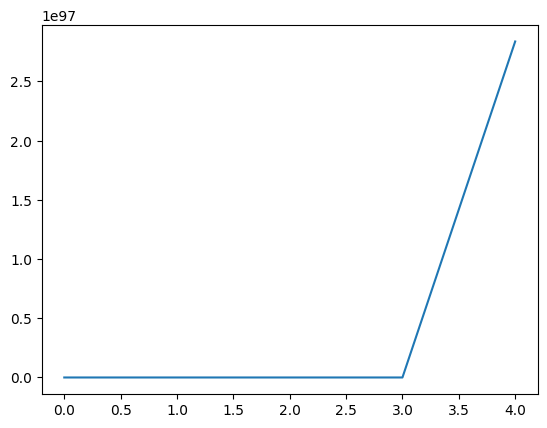

In [55]:
# entrenamos
W, costo_poly = gradiente_descendente_poly(Xtrain, Ytrain, eta = 0.0001, iteraciones=5, grado = 2)
plt.plot(range(5), costo_poly)

In [56]:
# completa los parametros para evaluar el modelo
error_test = evaluar_modelo_poly(W, X_to_test = Xtest,  Y_True = Ytest, grado = 2)
print("error en la evaluación del modelo", error_test)

error en la evaluación del modelo 1.315095181719853e+90


## Ejercicio 5: Normalización

En nuestro primer experimento vamos a evaluar el rendimiento del modelo usando varias tasas de aprendizaje y grados de polinomios. Vamos a dejar por ahora un número de iteraciones fijas = 5. Para ello completa la siguiente función.



In [58]:
## Ejercicio de codigo
def experimentar(Xtrain, Xtest, Ytrain, Ytest, tasas, grados):
    """Función para realizar experimentos con diferentes tasas de aprendizaje y grados polinomiales.

    Xtrain: Conjunto de datos de entrenamiento.
    Xtest: Conjunto de datos de evaluación.
    Ytrain: Salidas reales del conjunto de entrenamiento.
    Ytest: Salidas reales del conjunto de evaluación.
    tasas: Lista con los valores numéricos de tasas de aprendizaje para experimentar.
    grados: Lista con los valores numéricos de grados polinomiales para experimentar.

    Retorna:
        - Un DataFrame con los resultados de los experimentos.
    """
    numero_iter = 5
    resultados = pd.DataFrame()
    idx = 0  # Índice para el DataFrame

    for eta in tasas:
        for grado in grados:
            # Entrenar el modelo con la configuración actual
            W, _ = gradiente_descendente_poly(Xtrain, Ytrain, eta, numero_iter, grado)

            # Evaluar el error en el conjunto de prueba
            error = evaluar_modelo_poly(W, Xtest, Ytest, grado)

            # Guardar los resultados en el DataFrame
            resultados.loc[idx, 'grado'] = grado
            resultados.loc[idx, 'tasa de aprendizaje'] = eta
            resultados.loc[idx, 'ecm'] = error
            idx += 1

    return resultados

In [59]:
## Ahora ejecutamos la función desarrollada para ver los resultados
tasas_aprendizaje = [1e-6, 1e-5, 1e-3, 1e-2]
grados_polinomio = [1,2]
resultados_ex1 = experimentar(Xtrain, Xtest, Ytrain, Ytest, tasas_aprendizaje, grados_polinomio)

In [60]:
#Imprimimos los resultados
resultados_ex1

,grado,tasa de aprendizaje,ecm
0,1.0,0.000001,5.261729e+07
1,2.0,0.000001,1.315094e+70
2,1.0,0.000010,2.758117e+18
3,2.0,0.000010,1.315095e+80
4,1.0,0.001000,3.257954e+38
5,2.0,0.001000,1.315095e+100
6,1.0,0.010000,3.262850e+48
7,2.0,0.010000,1.315095e+110


Si has implementado todo correctamente, parecieria que nuestros entrenamientos no esta logrando buenos resultados (hasta parece haber errores infinitos! o no determinados!).

Crea una función que implemente la normalización z-score: $\bar{x} = \frac{x-\mu}{\sigma}$. Debe estimar los parámetros de la normalización con los datos de entrenamiento y aplicar la normalización tanto a los datos de entrenamiento como a los de test.


In [61]:
## Ejercicio de codigo
def normalizar(Xtrain, Xtest):
    """Función para normalizar los datos usando z-score.

    Xtrain: Matriz de datos de entrenamiento a normalizar.
    Xtest: Matriz de datos de evaluación a normalizar.

    Retorna:
        - Xtrain_n: Matriz normalizada de entrenamiento.
        - Xtest_n: Matriz normalizada de evaluación.
    """
    # Calcular la media y desviación estándar solo con los datos de entrenamiento
    media = np.mean(Xtrain, axis=0)
    desviacion = np.std(Xtrain, axis=0)

    # Aplicar la normalización z-score
    Xtrain_n = (Xtrain - media) / desviacion
    Xtest_n = (Xtest - media) / desviacion  # Se normaliza usando media y desviación del entrenamiento

    # Si hay divisiones por cero, reemplazar los NaN con ceros
    Xtrain_n = np.nan_to_num(Xtrain_n)
    Xtest_n = np.nan_to_num(Xtest_n)

    return Xtrain_n, Xtest_n

**Registra tu solución en línea**

In [62]:
student.submit_task(namespace=globals(), task_id='T5');

Ahora vuelve a realizar los mismos experimentos, pero esta vez usa los valores de salida de la función anterior.

In [63]:
Xtrain_n, Xtest_n = normalizar(Xtrain, Xtest)

In [64]:
resultados_ex2 = experimentar(Xtrain_n, Xtest_n, Ytrain, Ytest, tasas_aprendizaje, grados_polinomio)
#para ver los resultados
resultados_ex2

,grado,tasa de aprendizaje,ecm
0,1.0,0.000001,1497.368268
1,2.0,0.000001,1496.114867
2,1.0,0.000010,1496.712257
3,2.0,0.000010,1484.226466
4,1.0,0.001000,1426.305217
5,2.0,0.001000,598.104636
6,1.0,0.010000,923.779072
7,2.0,0.010000,14.446051


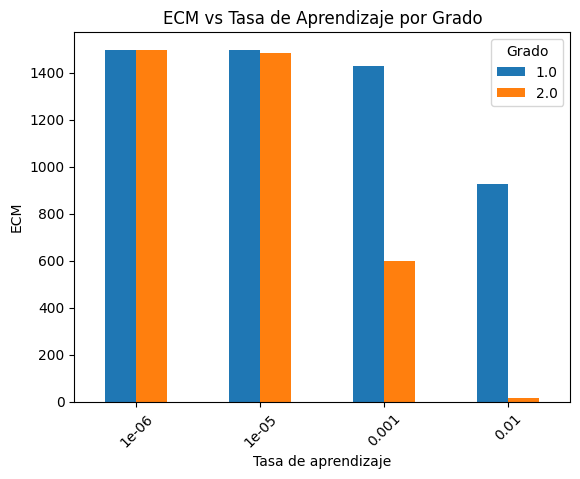

In [65]:
# ejecuta esta linea de codigo para graficar tus resultados
import matplotlib.pyplot as plt

# Grouping the data for plotting
grouped = resultados_ex2.groupby(['tasa de aprendizaje', 'grado'])['ecm'].mean().unstack()

# Creating the bar plot
fig, ax = plt.subplots()
grouped.plot(kind='bar', ax=ax)

# Labels and title
ax.set_xlabel('Tasa de aprendizaje')
ax.set_ylabel('ECM')
ax.set_title('ECM vs Tasa de Aprendizaje por Grado')

# Adding legend
ax.legend(title='Grado')

plt.xticks(rotation=45)  # Rotate x-axis labels if necessary
plt.show()

Ten en cuenta el resutaldo de los  dos experimentos y  responde la  siguiente pregunta abierta

In [68]:
# Pregunta abierta
#¿Qué proceso hace la normalización sobre los datos? Consulte qué es el número de condición de una matriz y analice qué relación tiene ese concepto con el proceso de normalización
respuesta = "Con la normalización buscamos ajustar la escala de los datos para evitar que unas variables dominen sobre otras.  El número de condición de una matriz mide su sensibilidad a pequeñas variaciones; si es alto, el modelo puede ser inestable. La normalización reduce este número mejorando la precisión del modelo"

In [69]:
# Pregunta abierta
#¿cuáles son los tipos de normalización más comunes. ¿Piensa en cuándo es más apropiado usar uno u otro?
respuesta = "Min-Max, Z-Score, Robust Scaling, logarítmica"

Finalmente, en nuestro tercer experimento, vamos a ver el efecto de las iteraciones sobre el error. Completa la siguiente función. Esta vez la tasa de aprendizaje es constante.

In [70]:
## ejercicio de codigo
import pandas as pd
import numpy as np

def experimentar_2(Xtrain, Xtest, Ytrain, Ytest, iteraciones, grados):
    """Función para realizar experimentos con diferentes números de iteraciones.

    Xtrain: Conjunto de datos de entrenamiento.
    Xtest: Conjunto de datos de evaluación.
    Ytrain: Salidas reales del conjunto de entrenamiento.
    Ytest: Salidas reales del conjunto de evaluación.
    iteraciones: Lista con los valores de iteraciones para experimentar.
    grados: Lista con los valores de grados polinomiales a probar.

    Retorna:
        - Un DataFrame con los resultados de los experimentos.
    """
    eta = 1e-2  # Tasa de aprendizaje fija
    resultados = pd.DataFrame()
    idx = 0  # Índice para almacenar los resultados

    for itera in iteraciones:
        for grado in grados:
            # Entrenar el modelo con la configuración actual
            W, _ = gradiente_descendente_poly(Xtrain, Ytrain, eta, itera, grado)

            # Evaluar el error cuadrático medio en el conjunto de prueba
            error = evaluar_modelo_poly(W, Xtest, Ytest, grado)

            # Guardar los resultados en el DataFrame
            resultados.loc[idx, 'iteraciones'] = itera
            resultados.loc[idx, 'grado'] = grado
            resultados.loc[idx, 'ecm'] = error
            idx += 1

    return resultados


In [71]:
num_iters = [1,5,10,50, 100,200, 1000, 2000]
grados_polinomio = [1,2]
# usamos la función para evaliar los resultados
resultados_ex3 = experimentar_2(Xtrain_n, Xtest_n, Ytrain, Ytest, num_iters, grados_polinomio )

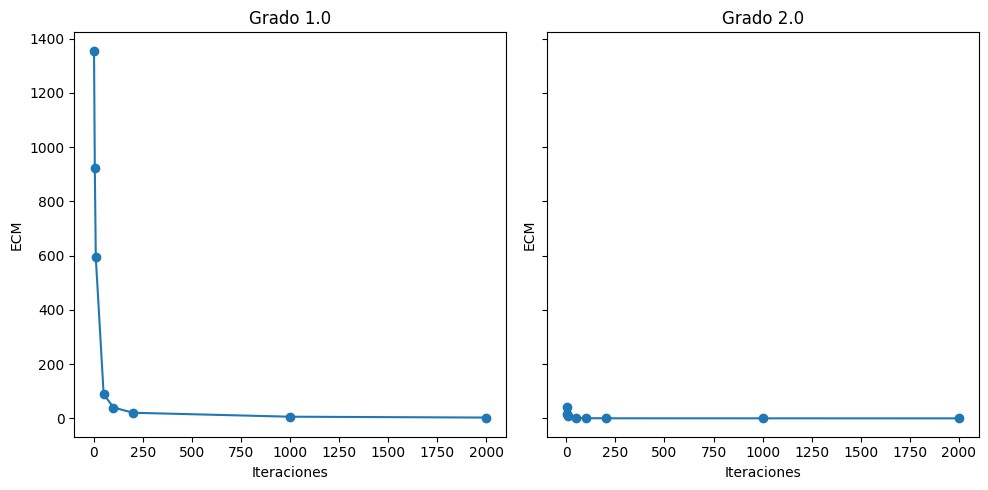

In [72]:
# ejecuta esta linea de código para ver gráficamente tus resultados
import matplotlib.pyplot as plt

grados = resultados_ex3['grado'].unique()
fig, axes = plt.subplots(1, len(grados), figsize=(5 * len(grados), 5), sharey=True)

if len(grados) == 1:
    axes = [axes]

for ax, grado in zip(axes, grados):
    subset = resultados_ex3[resultados_ex3['grado'] == grado]
    ax.plot(subset['iteraciones'], subset['ecm'], marker='o', linestyle='-')
    ax.set_title(f'Grado {grado}')
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('ECM')

plt.tight_layout()
plt.show()
